# 05 — 全年歷史需求與天氣整合

本 Notebook 使用 2023 年官方轉乘 YouBike 資料與 Open-Meteo 臺北單一參考點的歷史再分析天氣。需求僅代表公車／捷運轉乘族群；天氣不是每個站點的實測值。

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
monthly = pd.read_csv(ROOT / 'results/historical_monthly_summary.csv')
hourly = pd.read_csv(ROOT / 'results/historical_hourly_profile.csv')
quality = pd.read_csv(ROOT / 'results/historical_quality_summary.csv')
weather_quality = pd.read_csv(ROOT / 'results/weather_quality_summary.csv')
rain_hour = pd.read_csv(ROOT / 'results/weather_rain_hour_profile.csv')
quality

,metric,value
0,dataset_scope,transfer_related_trips_only
1,source_files,12
2,rows,7388479
3,date_start,2023-01-01
4,date_end,2023-12-31
5,timestamp_granularity,hour
6,raw_missing_cells,7
7,borrow_station_missing_rows,1
8,return_station_missing_rows,6
9,exact_duplicate_extra_rows_retained,16699


## 全年月需求
先確認月份覆蓋完整，再觀察季節差異。

,month,trip_count,average_trips_per_day,observed_days,average_unique_borrow_stations,trips_over_2h
0,2023-01,593616,19148.903226,31,980.387097,6088
1,2023-02,643304,22975.142857,28,1033.178571,6174
2,2023-03,736321,23752.290323,31,1058.129032,7108
3,2023-04,725241,24174.700000,30,1075.600000,8793
4,2023-05,809291,26106.161290,31,1092.483871,6328
5,2023-06,737985,24599.500000,30,1069.600000,5538
6,2023-07,533900,17222.580645,31,1019.387097,4716
7,2023-08,505654,16311.419355,31,993.032258,4518
8,2023-09,523099,17436.633333,30,1036.466667,4857
9,2023-10,516217,16652.161290,31,1026.451613,5198


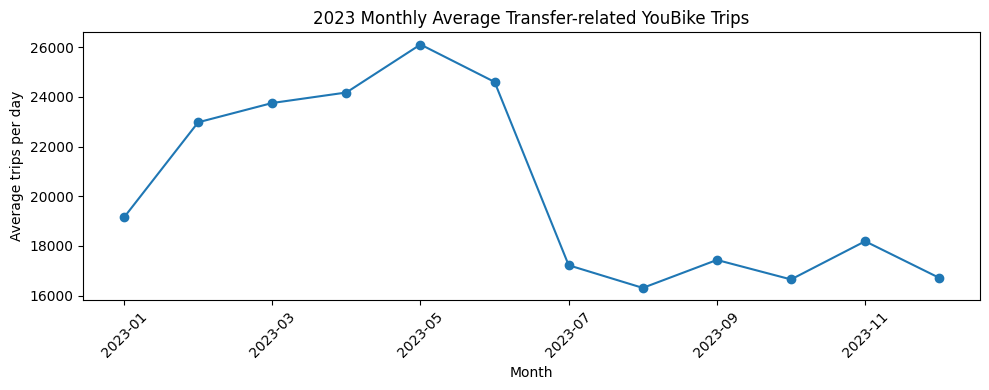

In [2]:
display(monthly)
ax = monthly.plot(x='month', y='average_trips_per_day', marker='o', figsize=(10, 4), legend=False)
ax.set(title='2023 Monthly Average Transfer-related YouBike Trips', xlabel='Month', ylabel='Average trips per day')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 平日與週末尖峰
平日與週末分開，避免把通勤型態混在一起。

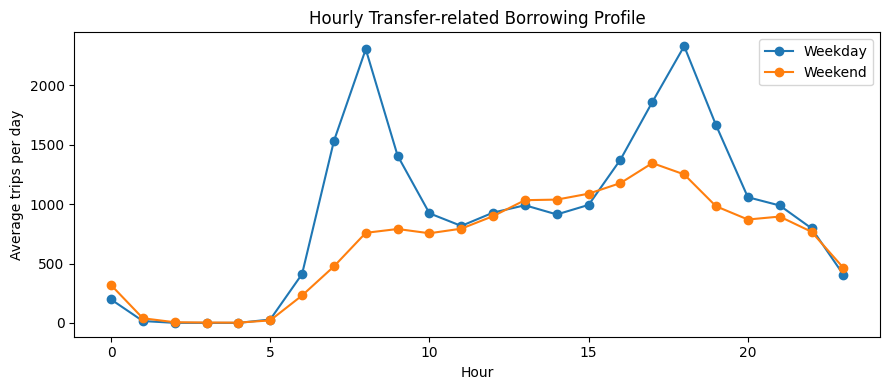

,is_weekend,borrow_hour,total_trips,average_trips_per_day,observed_days
18,False,18,606095,2331.134615,260
41,True,17,141356,1346.247619,105


In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
for is_weekend, group in hourly.groupby('is_weekend'):
    ax.plot(group['borrow_hour'], group['average_trips_per_day'], marker='o', label='Weekend' if is_weekend else 'Weekday')
ax.set(title='Hourly Transfer-related Borrowing Profile', xlabel='Hour', ylabel='Average trips per day')
ax.legend()
plt.tight_layout()
plt.show()
hourly.loc[hourly.groupby('is_weekend')['average_trips_per_day'].idxmax()]

## 天氣覆蓋與雨天差異

直接比較全年雨天與非雨天會混入時段與週末結構差異。因此下方只比較同為平日／週末、同一小時的 strata，並聚焦 06:00–23:00。這仍是描述性關聯，不能解讀為下雨造成需求下降的因果效果。

In [4]:
display(weather_quality)
pivot = rain_hour.pivot(index=['is_weekend', 'hour'], columns='is_raining', values=['average_borrows', 'observed_hours']).dropna()
hours = pivot.index.get_level_values('hour')
daytime = pivot.loc[(hours >= 6) & (hours <= 23)]
percent_change = (daytime[('average_borrows', True)] / daytime[('average_borrows', False)] - 1) * 100
rain_weights = daytime[('observed_hours', True)]
weighted_change = (percent_change * rain_weights).sum() / rain_weights.sum()
pd.Series({'daytime_strata': len(daytime), 'weighted_rain_change_percent': weighted_change, 'median_stratum_change_percent': percent_change.median()})

,metric,value
0,weather_source,Open-Meteo historical weather API
1,weather_scope,single_city_reference_point_reanalysis
2,weather_rows,8760
3,weather_date_start,2023-01-01T00:00:00+08:00
4,weather_date_end,2023-12-31T23:00:00+08:00
5,weather_missing_cells,0
6,weather_latitude,25.06151
7,weather_longitude,121.5194
8,demand_rows_weather_matched_percent,100.0


daytime_strata                   36.000000
weighted_rain_change_percent    -21.603764
median_stratum_change_percent   -22.417951
dtype: float64

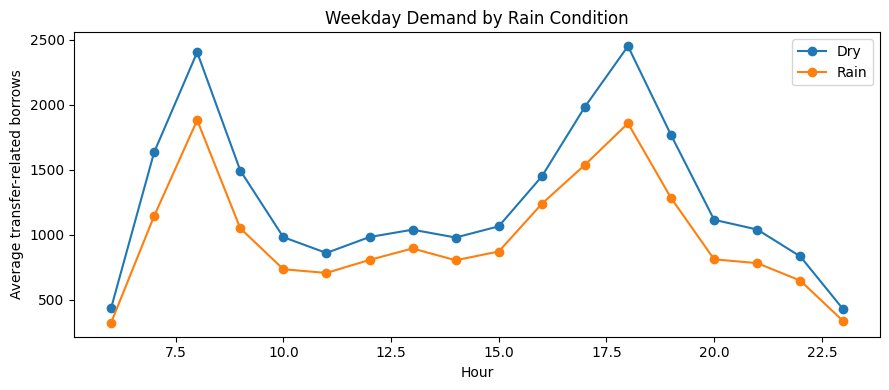

In [5]:
weekday = rain_hour.query('is_weekend == False and hour >= 6')
fig, ax = plt.subplots(figsize=(9, 4))
for raining, group in weekday.groupby('is_raining'):
    ax.plot(group['hour'], group['average_borrows'], marker='o', label='Rain' if raining else 'Dry')
ax.set(title='Weekday Demand by Rain Condition', xlabel='Hour', ylabel='Average transfer-related borrows')
ax.legend()
plt.tight_layout()
plt.show()

## 結論

全年資料確認月份、平假日與小時都有明顯結構；雨天在可比較的白天時段通常有較低的轉乘借車量。後續 Baseline Model 應使用時間順序切分，先比較只含時間／站點特徵的模型，再加入天氣特徵做增量驗證。